In [8]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.components.source import Source
from drtrex.sample import Sample


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(
    facility="ess-trex",
    neutrons=1_000_000,
    pulses=2,
    optimize_for=trex.choppers,
)
res_no_sample = trex.run()

In [9]:
sample = Sample(en={"uniform": (-40, 0)})
res = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_1995/2485097169.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


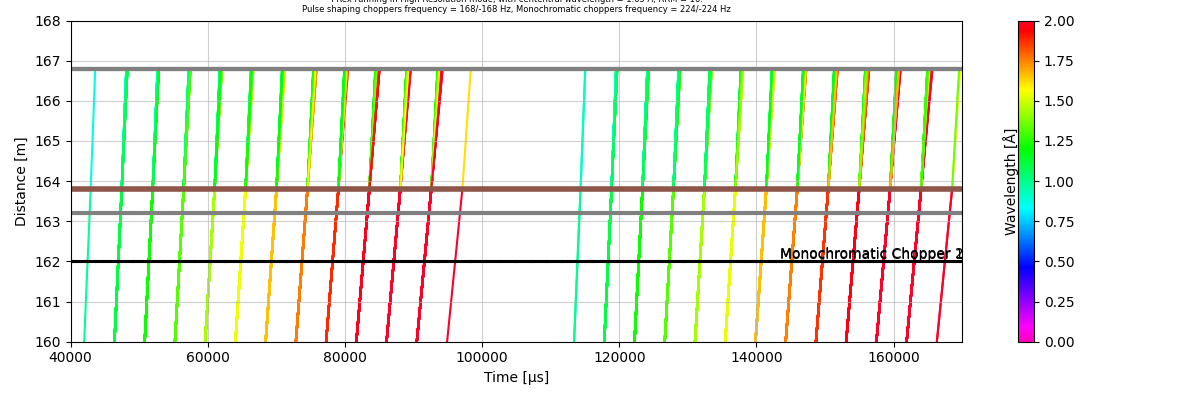

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

# res.plot(visible_rays=5_000_000, blocked_rays=50_000, ax=ax, vmin=0.0, vmax=2)
res.plot(ax=ax, vmin=0.0, vmax=2)
ax.set_xlim([40_000, 170_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

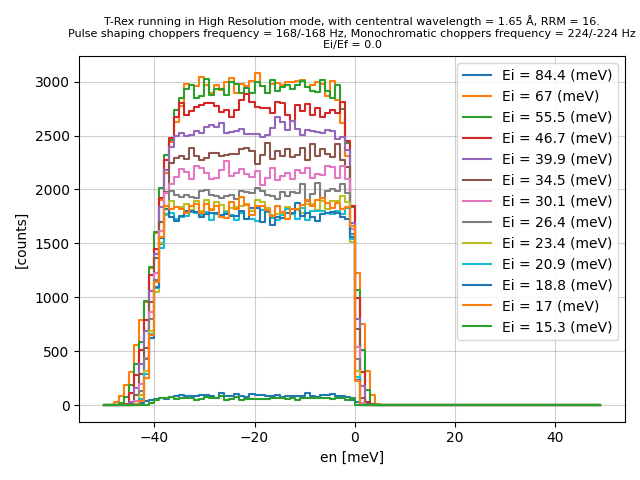

In [11]:
import plopp as pp

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 50, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

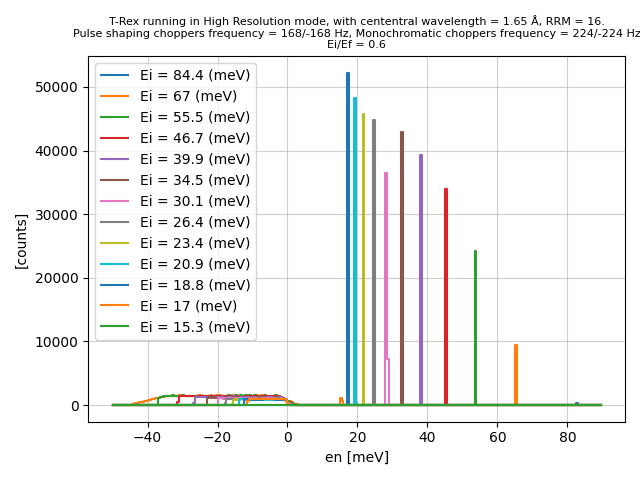

In [12]:
import plopp as pp

ei_ef_ratio = 0.6
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 90, 0.5, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)

fig.tight_layout()

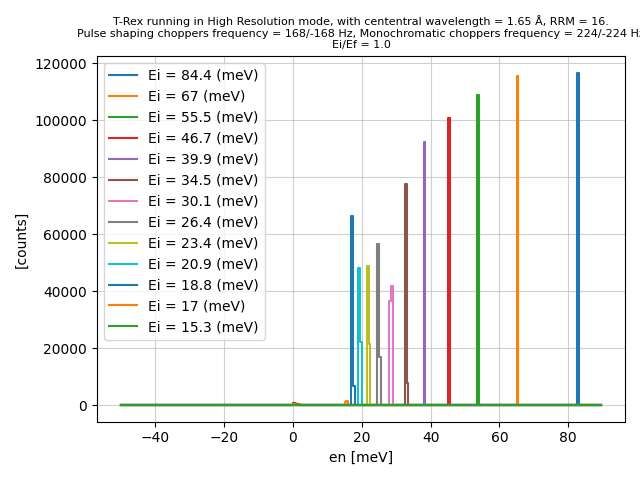

In [13]:
import plopp as pp

ei_ef_ratio = 1.0
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 90, 0.5, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)

fig.tight_layout()